# Exercise 1

## Preliminaries and imports

The cells below set up the Common Connectivity dataset reader, load the proofread cells, synapses, and cell types, and define the helper functions (`filter_synapse_table`, `make_adjacency`) used throughout this exercise. These are straight out of Module 2.

In [3]:
import sys
from os.path import join as pjoin
import os

# CodeOcean data asset and workshop utilities
mat_version = 1196
data_dir = f"/data/v1dd_{mat_version}_ccm"

project_id = "v1dd"
synapse_dataset_id = f"v1dd_{mat_version}_em"
synapse_feature_matrix_id = f"v1dd_{mat_version}_synapse_features"
axon_dataset_id = f"v1dd_{mat_version}_proofread_axons"
dendrite_dataset_id = f"v1dd_{mat_version}_proofread_dendrites"


# Set the directory to load prepared data and utility code
data_dir = pjoin(data_dir, f"v1dd_{mat_version}")

# Robustly locate the utils directory regardless of the kernel's working directory.
for _candidate in [pjoin("..", "utils"), pjoin("code", "utils"), "utils"]:
    if os.path.isdir(_candidate):
        utils_dir = os.path.abspath(_candidate)
        break
else:
    raise FileNotFoundError(
        "Could not locate the 'utils' directory. Current working directory: "
        f"{os.getcwd()}"
    )

# Add utilities to path
sys.path.append(utils_dir)

In [4]:
# Import packages
from connects_common_connectivity.io import DatasetReader, read_synapse_table

import pandas as pd
import polars as pl
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.sparse import csr_array
from typing import Union, Optional
from utils import adjacencyplot, cell_type_palette

In [5]:
# Initialize the Common Connectivity dataset reader
reader = DatasetReader(data_dir)
reader.display_dataset_names() # see available cohorts

FileNotFoundError: Dataset root does not exist or is not a directory: /data/v1dd_1196_ccm/v1dd_1196

In [ ]:
# Loads cells with axon and dendrite proofreading
proofread_axons = reader.read_dataset(axon_dataset_id)
proofread_dendrites = reader.read_dataset(dendrite_dataset_id)

dendrite_proof_root_ids = proofread_dendrites[
    "dataitem_id"
].cast(pl.UInt64).to_numpy()
axon_proof_root_ids = proofread_axons["dataitem_id"].cast(pl.UInt64).to_numpy()

print(
    f"There are {len(dendrite_proof_root_ids)} cells with acceptable dendrites, and {len(axon_proof_root_ids)} cells with axon proofreading"
)

In [ ]:
synapse_data = read_synapse_table(
    project_id,
    dataset_id=synapse_dataset_id,
    features=True,
    feature_matrix_id=synapse_feature_matrix_id,
    output_root=data_dir,
)

target_structure = (
    synapse_data.select(pl.col("id").cast(pl.UInt64), "synaptictargetlabel")
    .to_pandas()
    .set_index("id")["synaptictargetlabel"]
)

syn_df = (
    synapse_data.with_columns(
        pl.col("id").cast(pl.UInt64),
        pl.col("presynaptic_cell").cast(pl.UInt64),
        pl.col("postsynaptic_cell").cast(pl.UInt64),
    )
    .rename(
        {
            "presynaptic_cell": "pre_pt_root_id",
            "postsynaptic_cell": "post_pt_root_id",
        }
    )
    .select(
        [
            "id",
            "pre_pt_position_x",
            "pre_pt_position_y",
            "pre_pt_position_z",
            "post_pt_position_x",
            "post_pt_position_y",
            "post_pt_position_z",
            "ctr_pt_position_x",
            "ctr_pt_position_y",
            "ctr_pt_position_z",
            "size",
            "pre_pt_root_id",
            "post_pt_root_id",
        ]
    )
    .to_pandas()
)

print(syn_df.shape)

syn_df.head(3)

In [ ]:
def filter_synapse_table(
    synapse_table: pd.DataFrame, pre_root_ids=None, post_root_ids=None
):
    """Filter synapse table by pre and post root ids.

    Args:
        synapse_table: synapse table with pre_pt_root_ids and post_pt_root_ids as pd.DataFrame
        pre_root_ids: np.ndarray, list or pd.Series if root_ids to filter on the presynaptic side
        post_root_ids: np.ndarray, list or pd.Series if root_ids to filter on the postsynaptic side

    Returns:
        synapse_table: filtered synapse table
    """

    if pre_root_ids is not None:
        assert isinstance(pre_root_ids, (np.ndarray, list, pd.core.series.Series)), (
            f"IDs have to be of type np.ndarray, list or pd.Series; got {type(pre_root_ids)}"
        )
        pre_mask = np.isin(synapse_table["pre_pt_root_id"], pre_root_ids)
    else:
        pre_mask = np.ones(len(synapse_table), dtype=bool)

    if post_root_ids is not None:
        assert isinstance(post_root_ids, (np.ndarray, list, pd.core.series.Series)), (
            f"IDs have to be of type np.ndarray, list or pd.Series; got {type(pre_root_ids)}"
        )
        post_mask = np.isin(synapse_table["post_pt_root_id"], post_root_ids)
    else:
        post_mask = np.ones(len(synapse_table), dtype=bool)

    return synapse_table[pre_mask & post_mask]

In [ ]:
from utils import check_index


def make_adjacency(
    synapses,
    source_cell_index: Union[pd.Index, pd.DataFrame, pd.Series, np.ndarray, list],
    target_cell_index: Optional[
        Union[pd.Index, pd.DataFrame, pd.Series, np.ndarray, list]
    ] = None,
    aggfunc="binary",
    return_as="dense",
) -> Union[csr_array, np.ndarray]:
    source_cell_index = check_index(source_cell_index)
    if target_cell_index is None:
        target_cell_index = source_cell_index
    else:
        target_cell_index = check_index(target_cell_index)
    synapses = synapses.query(
        "pre_pt_root_id in @source_cell_index and post_pt_root_id in @target_cell_index"
    )
    groupby = synapses.groupby(["pre_pt_root_id", "post_pt_root_id"])
    if aggfunc == "count":
        edges = groupby.size().rename("weight").reset_index()
    elif aggfunc == "binary":
        edges = groupby.size().transform(lambda x: x > 0).rename("weight").reset_index()
    else:
        edges = groupby["size"].agg(aggfunc).rename("weight").reset_index()
    # make sure that the adjacency matrix is sorted the same as the input cell index
    edges["source_index"] = source_cell_index.get_indexer(edges["pre_pt_root_id"])
    edges["target_index"] = target_cell_index.get_indexer(edges["post_pt_root_id"])
    adjacency = csr_array(
        (edges["weight"], (edges["source_index"], edges["target_index"])),
        shape=(len(source_cell_index), len(target_cell_index)),
        dtype=edges["weight"].dtype,
    )
    # NOTE: for many applications working with sparse matrices is more efficient
    # but for ease of use and visualization in this workshop we return a dense matrix
    if return_as == "dense":
        adjacency = adjacency.todense()
    elif return_as == "sparse":
        pass  # already in sparse format
    else:
        raise ValueError(f"Unknown return_as type: {return_as}")
    return adjacency

In [ ]:
# get the ids of all proofread cells with both axon and dendrite proofreading
proof_root_ids = axon_proof_root_ids[
    np.isin(axon_proof_root_ids, dendrite_proof_root_ids)
]

# filter for synapses between the proofread cells (pre and post)
proof_proof_syn_table = filter_synapse_table(
    syn_df, pre_root_ids=proof_root_ids, post_root_ids=proof_root_ids
)

In [ ]:
cell_df = (
    proofread_dendrites
    .select(
        pl.col("dataitem_id").cast(pl.UInt64).alias("pt_root_id"),
        pl.col("soma_voxel_x").alias("pt_position_x"),
        pl.col("soma_voxel_y").alias("pt_position_y"),
        pl.col("soma_voxel_z").alias("pt_position_z"),
        (pl.col("soma_transformed_x") * 1_000).alias("pt_position_trform_x"),
        (pl.col("soma_transformed_y") * 1_000).alias("pt_position_trform_y"),
        (pl.col("soma_transformed_z") * 1_000).alias("pt_position_trform_z"),
        pl.col("soma_volume").alias("volume"),
        pl.col("v1dd_cell_types_level_1").alias("cell_type_coarse"),
        pl.col("v1dd_cell_types_level_2").alias("cell_type"),
    )
    .to_pandas()
)

cell_df.head()

In [ ]:
# Add a column that is soma depth in consistent units
cell_df['depth_um'] = cell_df['pt_position_trform_y'] / 1_000 # from nm to um

In [ ]:
# Filter the proofread ids for those with a known cell type
proof_root_ids = np.intersect1d(proof_root_ids, cell_df["pt_root_id"].values)

# Filter the cell type table for those with a proofread root id
proof_cell_df = cell_df.set_index("pt_root_id").loc[proof_root_ids]
proof_cell_df = proof_cell_df.query("cell_type.notna()")

# NOTE: the adjacency matrix will be sorted according to this dataframe's index, so
# we'll sort it by soma depth
proof_cell_df = proof_cell_df.sort_values("pt_position_trform_y")

## Connection specificity onto compartment types

Up until now we have considered all synapses between any two cells, but different synapses target different compartments on the postsynaptic cell.

![Synapse target structure diagram](../../figures/sss-diagram.png)

For example, it is common understanding that:

1. Synapses between excitatory and excitatory cells are onto spines.
2. Synapses between inhibitory and excitatory cells are onto dendritic shafts.
3. Synapses onto inhibitory cells are onto dendritic shafts.
4. Basket cells target soma synapses.

Let's test this textbook understanding in the real data.

For this you will need to load data about the target compartment of the synapse: spine, shaft, or soma.

In [ ]:
# Load the target structure included with the CCM synapse features
target_structure

# Select the synapses between proofread cells
proof_proof_syn_table = filter_synapse_table(
    syn_df, pre_root_ids=proof_root_ids, post_root_ids=proof_root_ids
).copy().set_index('id')

# Combine the target information to the proofread synapses table
proof_proof_syn_table["target_structure"] = target_structure
proof_proof_syn_table["target_structure"] = proof_proof_syn_table[
    "target_structure"
].fillna("unknown")

print(proof_proof_syn_table["target_structure"].value_counts())
proof_proof_syn_table.head()

target_structure
shaft      134631
spine       45679
soma        13248
unknown      1746
Name: count, dtype: int64


,pre_pt_position_x,pre_pt_position_y,pre_pt_position_z,post_pt_position_x,post_pt_position_y,post_pt_position_z,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,size,pre_pt_root_id,post_pt_root_id,target_structure
id,,,,,,,,,,,,,
461895313,917998.3,772740.8,284220.0,918376.6,772818.4,283815.0,918202.0,773080.3,284085.0,540,864691132557909513,864691132931817448,shaft
301049004,679950.6,813121.9,283050.0,679552.9,812753.3,283095.0,679601.4,812782.4,283140.0,958,864691132578625044,864691132931817448,shaft
436596114,879663.9,750576.3,347715.0,879266.2,750653.9,348120.0,879469.9,750634.5,347940.0,266,864691132557909513,864691132931817448,shaft
363374679,781538.7,726132.3,241110.0,781257.4,726268.1,240480.0,781305.9,725986.8,240705.0,396,864691132578625044,864691132786109590,shaft
491726200,962385.5,676759.3,316035.0,962210.9,677069.7,316620.0,962366.1,676856.3,316305.0,442,864691132562471396,864691132773784759,shaft


(<Axes: >, <utils.AxisGrid at 0x7fd439d05970>)

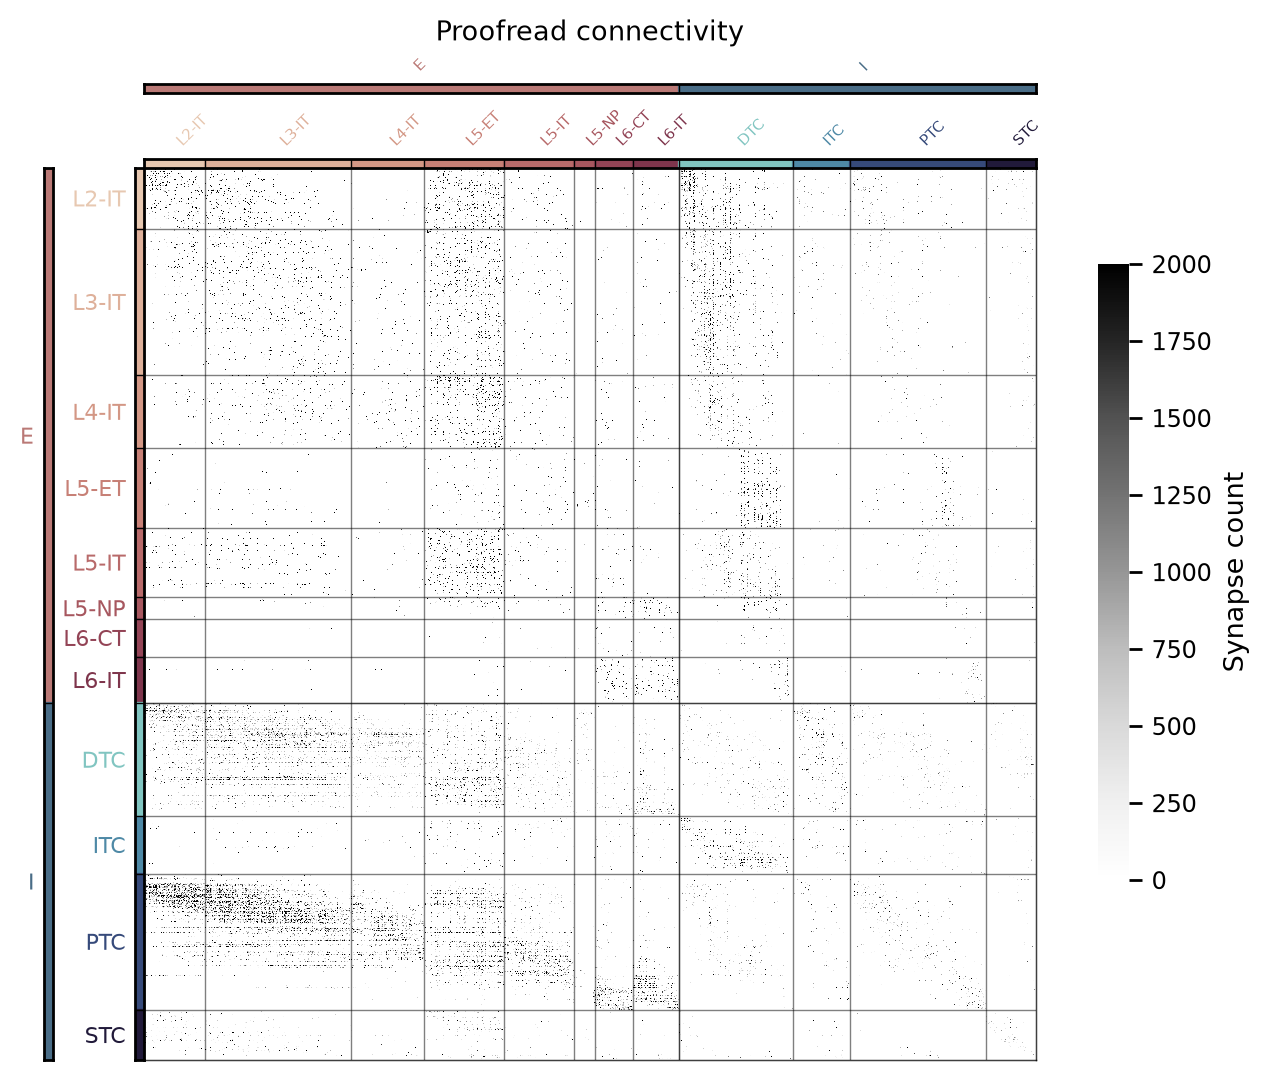

In [ ]:
## Plot just synapses onto spine

fig, ax = plt.subplots(figsize=(8, 8), dpi=200)

category = 'spine' # This is synapses onto spines

category_syns_df = proof_proof_syn_table.query(f"target_structure == '{category}'")
category_syn_mat = make_adjacency(
    category_syns_df, source_cell_index=proof_cell_df, aggfunc="sum"
)
# render the adjacency plot
adjacencyplot(
    category_syn_mat,  # data values for the points
    nodes=proof_cell_df,  # data to organize the x and y axis
    groupby=["cell_type_coarse", "cell_type"],  # categorical variables to organize by
    sortby="pt_position_y",  # sort within groups by variable
    node_palette=cell_type_palette,
    title="Proofread connectivity",
    edge_palette="Greys",
    hue_norm=(0, 2000),  # normalize the color scale for the edges
    ax=ax,
    label_fontsize="xx-small",
    title_fontsize="medium",
    arc_labels=False
)


#### Task 6: Compare target compartments

Reproduce the plot above for `shaft` and `soma` instead of `spine`.

#### Discussion

For each of the common cell-type connectivity assumptions above, which hold up in the data?

Find one thing that does not match your expectation and write it on the whiteboard.